# Big Data Analytics
### Trabajo individual – Convocatoria extraordinaria

---

# Active Learning con Apache Spark

### Diseño y evaluación de una solución escalable para la selección inteligente de instancias basada en incertidumbre y diversidad

---

**Máster Universitario en Ciencia de Datos e Ingeniería de Computadores (Universidad de Granada)**

- **Asignatura:** Big Data II
- **Autor:** David Fernández Martínez  
- **Email:** davidfm8@correo.ugr.es

# Entorno experimental

El proyecto ha sido realizado en un entorno Anaconda con *Python 3.8.10* y *Apache Spark 3.3.0*. La especificación completa del entorno se encuentra disponible en el fichero *enviroment.yml* que está basado en el recomendado en el material de la asignatura procedente del libro *Large-Scale Data Analytics with Python and Spark: A Hands-on Guide to Implementing Machine Learning Solutions: Isaac Triguero and Mikel Galar*.

Los experimentos se han ejecutado en un procesador *Intel Core i5-12500H de 12.ª* generación con $12$ núcleos físicos y $16$ procesadores lógicos, $15.67GB$ de RAM, y un sistema operativo *Microsoft Windows 11 Home*.

### Indice de contenidos
1. [Motivación y contexto](#motivacion)

2. [Formulación del problema](#formulacion)
   
3. [Diseño de la solución](#solucion)
    * [3.1 *load_and_preprocess_data()*](#load)
    * [3.2 *train_and_evaluate()*](#train)
    * [3.3 *get_uncertainty_candidates()*](#uncertainty)
    * [3.4 *diversity_k_means_selection()*](#diversity)

4. [Diseño de los experimentos](#experimentos)

5. [Discusión de resultados](#resultados)

<a id="motivacion"></a>
# 1. Motivación y contexto

El *Active Learning (AL)* es un paradigma de aprendizaje automático orientado a escenarios en los que la obtención de etiquetas presenta un coste elevado, debido tanto al tiempo requerido como a la necesidad de intervención de expertos. Por ejemplo, la clasificación de imágenes médicas o la detección de fenómenos físicos pueden requerir conocimientos especializados para llevar a cabo el proceso de etiquetado.

El objetivo de este paradigma es maximizar el rendimiento predictivo del modelo minimizando el número de instancias que deben ser etiquetadas. Para ello, se seleccionan las instancias que pueden aportar mayor información al modelo, por ejemplo, aquellas sobre las que presenta mayor incertidumbre. De este modo, el experto únicamente necesita etiquetar un subconjunto reducido de las muestras disponibles, disminuyendo el coste asociado al proceso de anotación. Las nuevas instancias etiquetadas se incorporan posteriormente al conjunto de entrenamiento, permitiendo reentrenar el modelo con el objetivo de mejorar su capacidad predictiva.

Aunque *Active Learning* busca reducir el número de instancias que deben ser etiquetadas, la selección de las muestras más informativas requiere evaluar todas las instancias disponibles mediante una estrategia de selección. Cuando el conjunto de datos es masivo, este proceso puede implicar un elevado coste computacional, convirtiendo la propia selección de instancias en un posible cuello de botella. Por tanto, la aplicación de *Active Learning* sobre grandes volúmenes de datos plantea un problema de procesamiento a gran escala, que requiere soluciones Big Data capaces de distribuir el procesamiento y aprovechar eficientemente los recursos computacionales disponibles.

En este contexto, el objetivo de este trabajo es abordar la siguiente cuestión experimental:

*¿Podemos diseñar una estrategia de selección de instancias para Big Data que evite que su coste computacional se convierta en el cuello de botella de Active Learning?*

<a id="formulacion"></a>
# 2. Formulación del problema

Active Learning se plantea como un proceso iterativo de selección y etiquetado de instancias, en el que se parte de un conjunto reducido de muestras etiquetadas (*Labeled, L*) y de un conjunto mayoritario de muestras sin etiquetar (*Unlabeled, U*). En cada iteración, el modelo se entrena utilizando las instancias disponibles en $L$ y se emplea para evaluar las muestras de $U$, con el objetivo de identificar aquellas que presentan un mayor potencial informativo para el aprendizaje. Las instancias seleccionadas son etiquetadas por el oráculo (experto), incorporadas al conjunto $L$ y utilizadas para reentrenar el modelo en la siguiente iteración, tal y como se ilustra en la siguiente figura:

<img src="images/active_learning_schema.png" width="40%">

La estrategia de selección planteada en este trabajo se estructura en dos fases consecutivas:
- **Filtrado basado en incertidumbre**. Se selecciona un subconjunto de instancias de $U$ sobre las que el modelo presenta mayor incertidumbre. De este modo, se descartan aquellas muestras sobre las que el modelo realiza predicciones con elevada confianza y se reduce el volumen de datos que debe procesarse en la siguiente fase, disminuyendo su coste computacional.
- **Selección basada en diversidad mediante K-Means**. Sobre el conjunto de candidatos obtenido se aplica *K-Means* para agrupar las instancias en función de la similitud de sus vectores de características. De cada clúster se selecciona la instancia más próxima a su centroide. De este modo, las instancias seleccionadas para etiquetar presentan incertidumbre y diversidad, ya que son potencialmente informativas para el modelo y, al mismo tiempo, cubren diferentes regiones del espacio de características, evitando la redundancia y favoreciendo la representatividad del conjunto de instancias seleccionado.

A continuación, se define formalmente la solución propuesta como un proceso iterativo de $T$ iteraciones, indexadas mediante $t \in \{0, \dots, T-1\}$, a partir de un conjunto de datos definido como:
$$N = \{(x_i, y_i)\}_{i=1}^{|N|}$$

donde $x_i \in \mathbb{R}^d$ representa el vector de características de la instancia $i$ y $y_i$ su etiqueta. Para evaluar la estrategia de selección de instancias, el conjunto $N$ se divide en dos subconjuntos disjuntos, utilizando un $70\%$ de las instancias para entrenamiento y un $30\%$ para evaluación:
$$
\begin{aligned}
|N_{\text{train}}| &= 0.70|N| \\
|N_{\text{test}}| &= 0.30|N|
\end{aligned}
$$

El conjunto de *test* se utiliza únicamente para evaluar el rendimiento predictivo del modelo en cada iteración. Por su parte, el conjunto de entrenamiento se divide inicialmente en un conjunto etiquetado $L_0$ y un conjunto no etiquetado $U_0$, de forma que:
$$N_{\text{train}} = L_0 \cup U_0, \quad L_0 \cap U_0 = \emptyset$$

Inicialmente, el $5\%$ del conjunto de entrenamiento se encuentra etiquetado, mientras que el $95\%$ restante permanece sin etiquetar:
$$
\begin{aligned}
|L_0| &= 0.05|N_{\text{train}}| \\
|U_0| &= 0.95|N_{\text{train}}|
\end{aligned}
$$

En cada iteración se selecciona un número $B$ de instancias (*query batch*) para que sean etiquetadas por el experto. Este valor se define como el $1\%$ del conjunto de entrenamiento:
$$B = \lfloor 0.01 |N_{\text{train}}| \rfloor$$

Para determinar el número de instancias consideradas en la fase de filtrado basada en incertidumbre, se utiliza un factor multiplicativo $\alpha$ sobre el tamaño del *query batch*. De este modo, la proporción de instancias de $U_t$, que se pretende conservar en esta fase viene dada por:
$$p_t = \min \left( 1, \frac{\alpha B}{|U_t|} \right)$$

donde $|U_t|$ representa el número de instancias no etiquetadas en la iteración $t$. A partir de esta proporción se define el cuantil:
$$q_t=1-p_t$$

Sea $u(x_i)$ la medida de incertidumbre asociada a una instancia $x_i \in U_t$. El conjunto de candidatos resultante $C_t$ se define seleccionando aquellas instancias cuya incertidumbre es igual o superior al valor correspondiente al cuantil $q_t$ de la distribución de incertidumbre en $U_t$:
$$C_t = \{ x_i \in U_t : u(x_i) \ge Q_{U_t}(q_t) \}$$
donde $Q_{U_t}(q_t)$ representa el cuantil $q_t$ de los valores de incertidumbre de las instancias pertenecientes a $U_t$.

Una vez obtenido el conjunto de candidatos $C_t$, se aplica la fase de selección por diversidad mediante *K-Means*. El algoritmo particiona $C_t$ en $B$ clústeres, donde $B$ es el *query batch*. Denotando por $K_j$ el conjunto de instancias asignadas al clúster $j$, para $j \in \{0, \dots, B-1\}$, y por $\mu_j$ su centroide, se selecciona de cada clúster la instancia cuya distancia al centroide es mínima:
$$x_j^* = \arg\min_{x_i \in K_j} d(x_i, \mu_j), \quad j \in \{0, \dots, B-1\}$$

donde $d(⋅,⋅)$ es la función de distancia empleada. De este modo, se obtiene una instancia representativa de cada clúster, definiendo el conjunto de muestras seleccionado para su etiquetado por el experto como:
$$Q_t = \{ x_0^*, x_1^*, \dots, x_{B-1}^* \}$$

Tras el etiquetado de las instancias seleccionadas, estas se incorporan al conjunto etiquetado y se eliminan del conjunto no etiquetado:
$$
\begin{aligned}
L_{t+1} &= L_t \cup Q_t \\
U_{t+1} &= U_t \setminus Q_t
\end{aligned}
$$

Finalmente, el modelo se reentrena utilizando el nuevo conjunto etiquetado $L_{t+1}$ y se evalúa sobre el conjunto de test $N_{test}$.

Una característica fundamental de la formulación propuesta es que los parámetros del algoritmo —el porcentaje inicial de instancias etiquetadas, el tamaño del *query batch* y la proporción de instancias seleccionadas en la fase de filtrado por incertidumbre— se definen de forma proporcional al tamaño del conjunto de datos. Esta configuración permite evaluar experimentalmente la escalabilidad de la solución al incrementar el tamaño del conjunto de datos, manteniendo las mismas proporciones.

> Los parámetros de configuración empleados se encuentran definidos en el fichero *scripts/config.py* y se mantienen consistentes en todos los experimentos realizados.

<a id="solucion"></a>
# 3. Diseño de la solución

El código de la solución desarrollada se encuentra en el fichero *scripts/AL_methods.py* y se estructura en varias funciones, cada una de las cuales implementa una etapa del algoritmo:
- *load_and_preprocess_data()*. Carga los datos y realiza el preprocesamiento necesario.
- *train_and_evaluate()*. Entrena el modelo con las instancias etiquetadas y evalúa su rendimiento sobre el conjunto de *test*.
- *get_uncertainty_candidates()*. Implementa la fase de filtrado basada en incertidumbre.
- *diversity_k_means_selection()*. Implementa la selección basada en diversidad mediante *K-Means* y simula el etiquetado por parte del experto de las instancias seleccionadas.

A continuación, se describe en detalle cada etapa de la solución, haciendo especial énfasis en las decisiones de diseño orientadas a garantizar un procesamiento eficiente y escalable en un entorno distribuido.

<a id="load"></a>
## 3.1 *load_and_preprocess_data()*

Esta función realiza la carga y preparación de los datos para el proceso de Active Learning:
- **Carga de los datos** mediante un Spark DataFrame, permitiendo que el procesamiento se distribuya entre las particiones disponibles.
- **Preprocesa las características**, convirtiéndolas a tipo *float* y agrupándolas en un único vector en la columna *features* mediante *VectorAssembler*.
- **Divide el conjunto de datos** en entrenamiento y test mediante *randomSplit()*, utilizando las proporciones definidas en la variable `TRAIN_TEST_SPLIT` de *scripts/config.py*.
- **Estandariza las características** mediante *StandardScaler*, necesario para la fase de diversidad basada en *K-Means*. El scaler se ajusta exclusivamente sobre el conjunto de entrenamiento y posteriormente se aplica tanto a entrenamiento como a test.
- **Inicializa el estado de las instancias del conjunto de entrenamiento** mediante una columna "*state*", asignando "$L$" (*Labeled*) a la fracción inicial de muestras etiquetadas y "$U$" (*Unlabeled*) al resto. La proporción inicial se establece mediante la variable `INITIAL_LABELED_FRACTION` en *scripts/config.py*. El DataFrame resultante presenta las columnas *id_sample*, *label*, *features* y *state*.

La función devuelve los DataFrames `train_df` y `test_df`, que se almacenan en caché. El conjunto de *test* se mantiene cacheado durante todo el proceso, ya que permanece inalterado y se utiliza en cada iteración para evaluar el modelo. Por su parte, `train_df` constituye el punto de partida de todas las operaciones de cada iteración, por lo que su almacenamiento en caché evita reconstruir repetidamente su linaje. Dado que su contenido cambia tras cada selección de instancias (la columna "*state*" cambia de "$U$" a "$L$" en las instancias seleccionadas), el DataFrame actualizado sustituye al anterior en caché, liberando previamente este último mediante *unpersist()*.

<a id="train"></a>
## 3.2 *train_and_evaluate()*

Esta función entrena el modelo utilizando las instancias etiquetadas de la iteración actual y evalúa su rendimiento sobre el conjunto de *test*. Está diseñada para trabajar con cualquier estimador de *Spark MLlib* y con las métricas compatibles con *MulticlassClassificationEvaluator*. De este modo, tanto el entrenamiento como la evaluación se ejecutan de forma distribuida sobre las particiones de los DataFrames.

La función devuelve el modelo entrenado, que se utiliza posteriormente para obtener predicciones sobre el conjunto no etiquetado $U$, y el valor de la métrica de evaluación.

En los experimentos se ha utilizado *LogisticRegression* debido a su capacidad para proporcionar estimaciones probabilísticas de pertenencia a las clases, necesarias para calcular la medida de incertidumbre empleada en la estrategia de selección. La métrica utilizada es *accuracy*, dado que el problema es de clasificación binaria y el conjunto de datos presenta una distribución de clases aproximadamente equilibrada (el conjunto de datos utilizado se describe en la siguiente sección).

<a id="uncertainty"></a>
## 3.3 *get_uncertainty_candidates()*

Esta función implementa el filtrado por incertidumbre para obtener un subconjunto de candidatos a partir del conjunto no etiquetado $U_t$ de la iteración $t$. El objetivo es concentrar la fase posterior de selección por diversidad en las instancias potencialmente más informativas y reducir el volumen de datos que debe procesarse.

Para ello, se filtra el DataFrame de entrenamiento para obtener las instancias de $U_t$ y se utiliza el modelo entrenado sobre las instancias etiquetadas, obtenido mediante *train_and_evaluate()*, para calcular las predicciones y probabilidades sobre $U_t$. Al tratarse de un problema de clasificación binaria, se emplea la siguiente medida de incertidumbre:
$$U(x) = 1 - 2 \left| P(y=1 \mid x) - 0.5 \right|$$
Esta medida toma valores en el intervalo $[0,1]$, donde $U(x)=1$ corresponde a la máxima incertidumbre, asociada a una probabilidad de $0.5$.

Tal y como se ha establecido en la formulación del problema, el tamaño del subconjunto de candidatos se determina mediante un factor multiplicativo $\alpha$ aplicado al *query batch* $B$. Una implementación directa consistiría en ordenar globalmente el conjunto de instancias no etiquetadas según su incertidumbre y seleccionar las $\alpha B$ instancias con mayor valor:
```python
candidates_df = unlabeled_df.orderBy("uncertainty", ascending=False).limit(alpha * B)
```

Sin embargo, la ordenación global requiere un *shuffle* entre las particiones, lo que puede generar un coste de comunicación y procesamiento elevado cuando $U_t$ es grande. Además, *limit()* suele forzar un reparticionado de los datos a una única partición, lo que limita el paralelismo de las operaciones posteriores, por lo que podría ser necesario realizar un *repartition()* adicional.

Como alternativa, se utiliza una estrategia basada en cuantiles aproximados. En esta fase no es necesario obtener exactamente las $\alpha B$ instancias con mayor incertidumbre ni establecer un orden global entre todas las muestras, basta con determinar un umbral que permita obtener un subconjunto de candidatos de tamaño aproximadamente $\alpha B$.

Para ello, se utiliza la función *ApproxQuantile()*, basada en el algoritmo *Greenwald-Khanna*, que permite estimar de forma distribuida un umbral asociado a un determinado cuantil de la distribución de valores. El valor de incertidumbre obtenido se utiliza posteriormente como umbral para filtrar el DataFrame y seleccionar las instancias que lo superan. Este filtrado se ejecuta de forma distribuida sobre las particiones del DataFrame, manteniendo los datos distribuidos para las etapas posteriores del procesamiento.

El resultado es el DataFrame `candidates_df`, que contiene las instancias seleccionadas como candidatas para la fase de diversidad.

<a id="diversity"></a>
## 3.4 *diversity_k_means_selection()*

La función *diversity_k_means_selection()* puede dividirse en tres procedimientos, cuya lógica algorítmica y distribución de las operaciones entre el Driver y los workers se ilustran en la siguiente imagen (disponible en *images/diversity_kmean_selection*). A continuación, se describe detalladamente cada uno de estas partes.

<img src="images/diversity_kmeans_selection.svg" width="80%">


**Agrupamiento de las instancias mediante Bisectic-KMeans**

En primer lugar, los candidatos previamente filtrados por incertidumbre se agrupan mediante clustering con $k=B$ clústeres, de modo que posteriormente pueda seleccionarse una instancia representativa de cada uno.

Como algoritmo de *clustering* se utiliza *BisectingKMeans* de *Spark MLlib* en lugar de *KMeans* convencional, ya que su estrategia de división jerárquica resulta especialmente adecuada cuando el número de clústeres es elevado. Mientras que *KMeans* calcula en cada iteración la asignación de las instancias respecto a los $k$ centroides, *BisectingKMeans* parte de un único clúster y realiza sucesivas divisiones binarias, reduciendo el número de centroides considerados simultáneamente y por tanto, el tráfico de información entre los nodos.

En este contexto, el objetivo del clustering no es obtener una partición óptima del espacio de características, sino proporcionar una distribución suficientemente diversa de los candidatos para seleccionar instancias representativas y poco redundantes. Por ello, se prioriza la eficiencia y escalabilidad frente a una posible mejora en la calidad del agrupamiento.

Dado que la implementación de *BisectingKMeans* de *MLlib* es distribuida, tanto el ajuste del modelo como la asignación de las instancias a los clústeres se ejecutan de forma distribuida. Como resultado, se obtiene el DataFrame `clustered_candidates_df`, que incorpora la columna *cluster_id* con el clúster asignado a cada instancia.

**Selección de la instancia más cercana al centroide de cada clúster**

El objetivo de esta etapa es seleccionar una única instancia representativa por clúster, concretamente aquella cuya distancia al centroide sea mínima. Para ello, los $B$ centroides se distribuyen mediante *broadcast*, de modo que cada *worker* pueda acceder localmente a ellos durante el procesamiento de las instancias. 

Dado que los candidatos de un mismo clúster pueden estar distribuidos entre diferentes particiones, todas ellas necesitan acceder a los mismos centroides. El uso de *broadcast* permite disponer de esta información localmente y evita su redistribución repetida durante el procesamiento.

El cálculo de la distancia entre cada instancia y el centroide de su clúster se realiza localmente. Para ello, el DataFrame `clustered_candidates_df` se transforma en un RDD cuyos elementos tienen la siguiente estructura:
$$(clave, valor) = (cluster\_id, (id\_sample, distance))$$
De este modo, se conserva únicamente la información necesaria para identificar el candidato más próximo a cada centroide, reduciendo el volumen de datos que debe procesarse durante la agregación.

Sobre este RDD se aplica *reduceByKey()*, que permite realizar la selección de forma distribuida de la siguiente forma:
- **Agregación local**. En cada partición se obtiene el candidato con menor distancia para cada *cluster_id*.
- **Shuffle**. Los resultados parciales se redistribuyen entre las particiones en función de *cluster_id*, de modo que los candidatos correspondientes a un mismo clúster quedan agrupados.
- **Reducción global.** Se comparan los candidatos recibidos para cada *cluster_id* y se obtiene aquel con menor distancia.

Como resultado, se obtiene el RDD distribuido `closest_per_cluster_rdd`, que contiene un único representante, el más próximo al centroide, por cada clúster.

**Actualización del estado de etiquetado mediante Broadcast Hash Join**

Esta fase simula el etiquetado del oráculo actualizando de "$U$" a "$L$" el estado de las $B$ instancias seleccionadas en el DataFrame `train_df`. Para ello, se extraen los *id_sample* de `closest_per_cluster_rdd` y se obtiene el DataFrame `selected_ids_df`, que contiene únicamente los identificadores de las instancias seleccionadas.

Dado que este DataFrame contiene solo $B$ identificadores frente al tamaño considerablemente mayor de `train_df`, se utiliza un *Broadcast Hash Join*. Los identificadores se replican en los *workers*, permitiendo realizar el *join* localmente sobre las particiones de `train_df` y evitando un *shuffle* del conjunto de entrenamiento lo que reduce el tráfico de red.

<a id="experimentos"></a>
# 4. Diseño de los experimentos

Para la evaluación experimental de la solución se utiliza el conjunto de datos HIGGS, disponible en el UCI Machine Learning Repository [UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/280/higgs). Se trata de un problema de clasificación binaria orientado a distinguir entre procesos que producen bosones de Higgs y procesos de fondo. El conjunto de datos contiene 11 millones de instancias, cada una descrita mediante 28 características.

Debido a las limitaciones de recursos del entorno local utilizado para la experimentación, se emplea una muestra de 1 millón de instancias del conjunto original como tamaño de referencia. A partir de ella, se generan subconjuntos correspondientes al $80\%$, $40\%$, $20\%$ y $10\%$ para las pruebas de escalabilidad.

En el fichero *data/data_info.md* se detallan las instrucciones para descargar el dataset original y generar los mismos subconjuntos utilizados en la experimentación mediante la ejecución de *scripts/download_data.py.*

Se han diseñado dos tipos de experimentos con objetivos diferenciados: 
- **Experimento de rendimiento.** Su objetivo es validar que la solución implementada presenta el comportamiento esperado de un algoritmo de *Active Learning*, es decir, que la selección inteligente de instancias permite mejorar el rendimiento predictivo mediante la incorporación progresiva de muestras informativas. Para ello, se ejecutan $10$ iteraciones del algoritmo, registrando el *accuracy* obtenido en cada iteración junto al porcentaje de datos etiquetado. La estrategia propuesta se compara con una estrategia de selección aleatoria, implementada mediante la función *random_selection()* de *scripts/AL_methods.py*.
- **Experimentos de escalabilidad.** Tienen como objetivo evaluar la escalabilidad de la solución, midiendo el tiempo de ejecución de una única iteración del algoritmo bajo diferentes configuraciones del número de cores y tamaño del dataset. Los resultados obtenidos permiten cuantificar las medidas de *Speed-up*, *Size-up* y *Scale-up*.

La siguiente imagen muestra el flujo de ejecución diseñado para cada tipo de experimento, incluyendo las funciones involucradas, las etapas en las que se almacenan los DataFrames en caché y, para los experimentos de escalabilidad, el punto concreto en el que se realiza la medición del tiempo de ejecución. La lógica correspondiente se encuentra implementada en *scripts/AL_performance.py* y *scripts/AL_scalability.py*.


<img src="images/experiment_design.svg" width="100%">

Las ejecuciones y configuración de los experimentos se encuentran disponibles en los notebooks *performance_experiment.ipynb* y *scalability_experiments.ipynb* que hacen uso de *scripts/AL_performance.py* y *scripts/AL_scalability.py* respectivamente. Los resultados obtenidos se almacenan en la carpeta *results/* y se discuten en la siguiente sección.

<a id="resultados"></a>
# 5. Discusión de resultados

**Rendimiento**

En primer lugar, se analizan los resultados obtenidos en el experimento de rendimiento, almacenados en el fichero *results/performance.csv*. Para evaluar el comportamiento de la solución de *Active Learning*, se representa la evolución del accuracy en función del porcentaje de instancias etiquetadas. Esta representación permite analizar la capacidad del método de selección de instancias para mejorar el rendimiento del modelo a medida que se incrementa progresivamente la cantidad de datos disponibles para su entrenamiento

method,labeled_percentage,Random,Uncertainty + Diversity
0,5.0,0.6381,0.6381
1,6.0,0.6377,0.6408
2,7.0,0.6389,0.6427
3,8.0,0.6396,0.6451
4,9.0,0.6395,0.6463
5,10.0,0.6403,0.6471
6,11.0,0.6409,0.6482
7,12.0,0.6409,0.6482
8,13.0,0.6414,0.6488
9,14.0,0.6416,0.6497


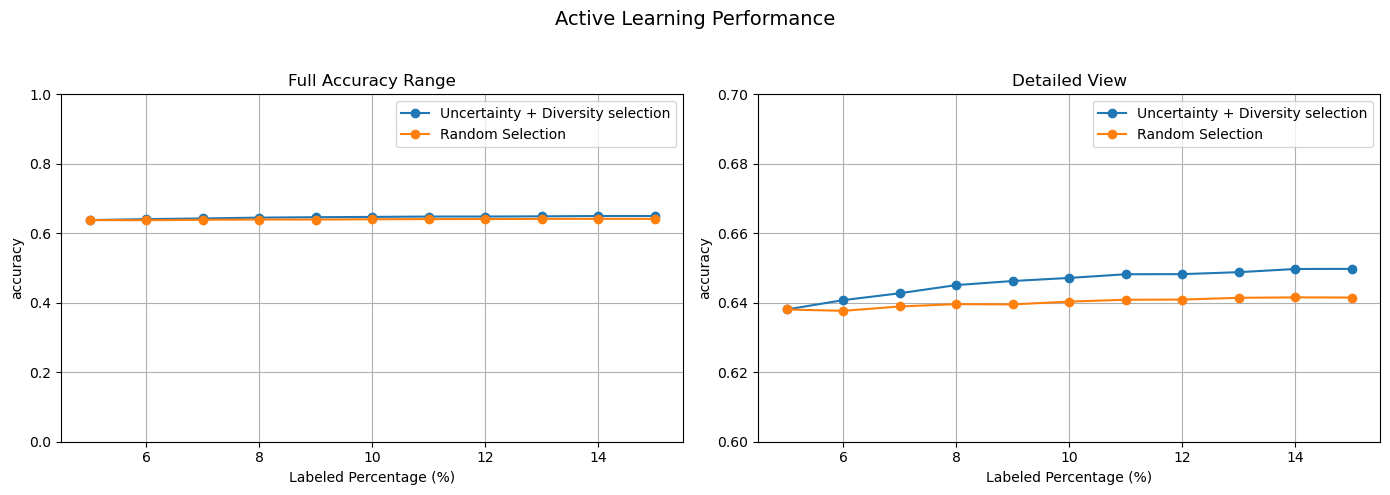

In [2]:
from scripts.plot_results import plot_performance_results

plot_performance_results("performance.csv")

Los resultados muestran que la estrategia de selección basada en incertidumbre y diversidad proporciona una mejora progresiva del accuracy, mientras que en la selección aleatoria el incremento es más reducido manteniendose constante entre determinadas iteraciones.

El máximo *accuracy* alcanzado mediante la estrategia de selección aleatoria, de $0.6415$ con un $15\%$ de datos etiquetados, es superado por la estrategia basada en incertidumbre y diversidad a partir de un $7\%$ de datos etiquetados. La mejora de la selección aleatoria se debe al aumento progresivo de instancias etiquetadas, mientras que en la estrategia inteligente se prioriza las instancias más informativas para el modelo. De este modo, se consigue un aprovechamiento más eficiente del presupuesto de etiquetado, alcanzando un rendimiento superior con una menor cantidad de datos etiquetados.

No obstante, las diferencias de rendimiento entre ambas estrategias, así como el incremento del *accuracy* entre iteraciones, son moderadas. El objetivo del experimento no es cuantificar el máximo beneficio potencial de *Active Learning*, sino validar experimentalmente el correcto funcionamiento de la estrategia de selección desarrollada, comprobando que presenta el comportamiento esperado frente a un *baseline*. 

La efectividad de *Active Learning* depende no solo de la estrategia de selección empleada, sino también del modelo de aprendizaje utilizado y de las características del dataset.  En este sentido, una línea de trabajo futuro consistiría en evaluar la solución sobre datasets de distinta complejidad, incluyendo problemas multiclase y desbalanceados, así como utilizar modelos de *MLlib* de mayor complejidad que *LogisticRegression*.

**Escalabilidad**

A continuación, se presentan los resultados obtenidos en los experimentos de *Speed-Up*, *Size-Up* y *Scale-Up*, cuyos datos se almacenan, respectivamente, en los ficheros *results/speed_up.csv*, *results/size_up.csv* y *results/scale_up.csv*.

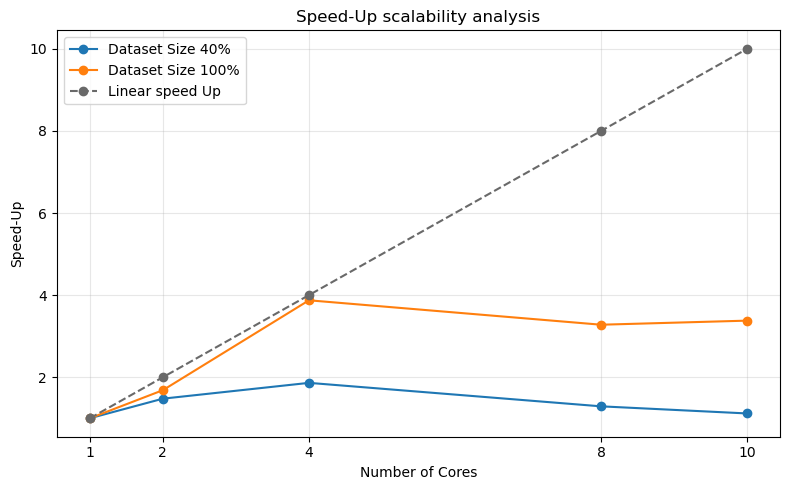

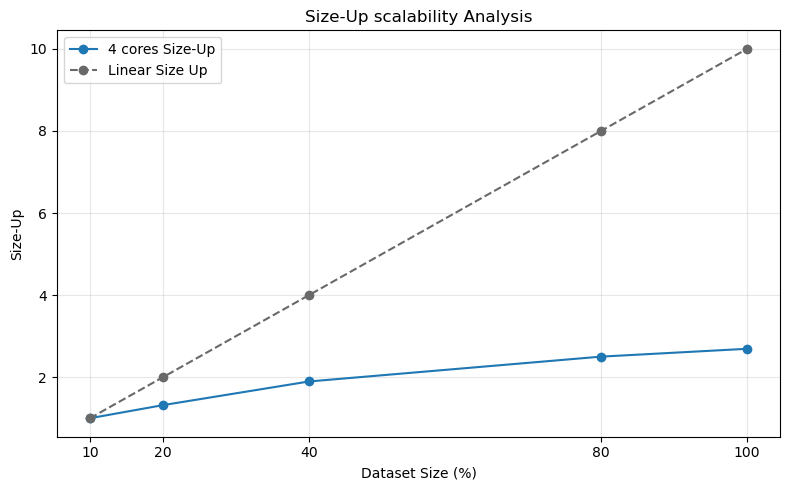

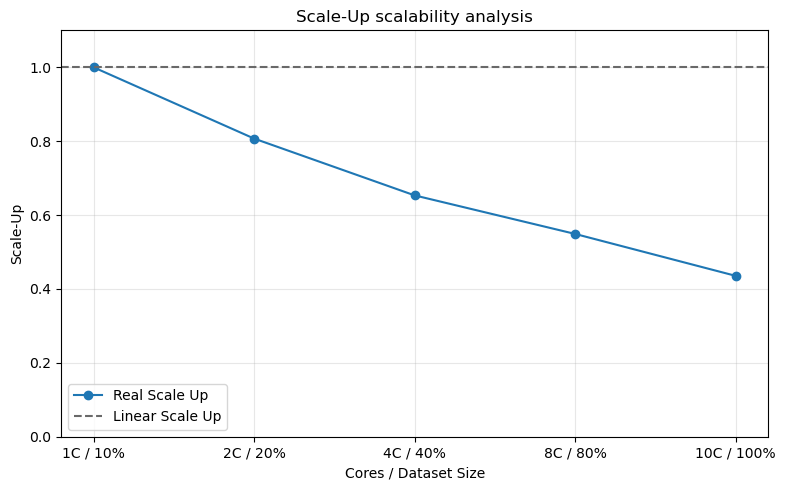

In [3]:
from scripts.plot_results import plot_scalability

plot_scalability("speed_up.csv", "size_up.csv", "scale_up.csv")

Para evaluar el ***Speed-Up*** se consideran dos tamaños del dataset ($40\%$ y $100\%$) y se varía el número de cores en $[1,2,4,8,10]$. El tiempo de referencia se toma respecto a $1$ core.

En ambos casos, se observa una mejora progresiva del *Speed-Up* hasta alcanzar los $4$ cores, donde se obtiene el mejor tiempo de ejeucicón. A partir de este punto, un incremento adicional del grado de paralelismo no proporciona mejoras significativas.

A pesar de que la tendencia observada es similar para ambos tamaños del dataset, la magnitud del *Speed-Up* presenta diferencias significativas. Para el $100\%$ de los datos (1 millón de muestras), el comportamiento entre $1$ y $4$ cores es prácticamente lineal, alcanzándose un *Speed-Up* de $3.87$ con $4$ cores. En cambio, para el $40\%$ del dataset, la mejora es más limitada, con un *Speed-Up* de $1.86$ con $4$ cores.

Este comportamiento sugiere que, para un menor volumen de datos, los sobrecostes asociados a la ejecución distribuida de Spark (*Spark overhead*), como la planificación y coordinación de tareas, representan una proporción mayor del tiempo de ejecución y limitan el beneficio obtenido mediante el paralelismo.
En la implementación desarrollada hay operaciones que requieren *shuffle* y se hace uso de *broadcast* en la fase de diversidad. Aunque esta última operación pueda evitar la redistribución de grandes volúmenes de datos, introduce costes de comunicación que contribuyen al *Spark OverHead*.

En cambio, con el $100\%$ del dataset, el mayor volumen de datos permite aprovechar más eficientemente el paralelismo y amortizar los sobrecostes de *Spark* en el rango de $1$ a $4$ cores.

A partir de $8$ cores el *Speed-Up* deja de mejorar en ambos tamaños del *dataset* por lo que el aumento de recursos deja de ser beneficioso y el tiempo de ejecución se ve dominado por el *Spark overhead*. 

Para evaluar el ***Size-Up***, se fijan $4$ cores, al haber obtenido el mejor rendimiento en el experimento de *Speed-Up*, y se evalúan los tamaños de dataset definidos: $[10\%, 20\%, 40\%, 80\%, 100\%]$. Como referencia, se toma el tiempo de ejecución correspondiente al $10\%$ del dataset.

Los resultados muestran que el *Size-Up* crece de forma significativamente inferior al comportamiento lineal esperado. El incremento del tamaño del dataset del $10\%$ al $100\%$ supone un aumento del tiempo medio de ejecución de aproximadamente $2.69$.

Este resultado indica que el incremento del volumen de datos se gestiona de forma eficiente mediante la ejecución paralela, sin que el tiempo de ejecución aumente proporcionalmente al tamaño del dataset. Este comportamiento resulta favorable desde el punto de vista de la escalabilidad, aunque debe interpretarse dentro del rango de volúmenes evaluado, comprendido entre 100.000 muestras ($10\%$) y 1.000.000 de muestras ($100\%$).

Para medir el ***Scale Up*** se evaluan las parejas de número de cores y tamaño del dataset: 1 core–$10\%$, 2 cores–$20\%$, 4 cores–$40\%$, 8 cores–$80\%$ y 10 cores–$100\%$, tomando como referencia el tiempo obtenido con 1 core–$10\%$.

Los resultados muestran que, aunque la solución no presenta un *Scale-Up* ideal constante, la disminución es progresiva a medida que aumentan simultáneamente los recursos y el volumen de datos. Esto indica que el incremento de los recursos computacionales permite absorber gran parte del aumento de la carga de trabajo, evitando que el tiempo de ejecución crezca proporcionalmente al tamaño del dataset.

Concretamente, al pasar de 1 core–$10\%$ a 10 cores–$100\%$, el volumen de datos y los recursos se multiplican por $10$, mientras que el tiempo medio de ejecución pasa de $35.98$ s a $82.64$ s, un incremento de aproximadamente $2.30$. Por tanto, aunque existe una pérdida respecto al escalado ideal, la solución consigue procesar diez veces más datos con diez veces más recursos con un incremento temporal muy inferior al lineal.


Puede concluirse que la solución presenta un comportamiento favorable en términos de escalabilidad, aprovechando de forma efectiva el paralelismo hasta los $4$ cores y mostrando un crecimiento del *Size-Up* inferior al lineal. La evaluación con volúmenes de datos mayores podría modificar el aprovechamiento de un mayor número de cores, como sugiere el experimento de *Speed-Up*, en el que los datasets de mayor tamaño permiten amortizar en mayor medida los sobrecostes de*Spark* y aprovechar más eficientemente el paralelismo.